## Prosty klasyfikator


## z wymagań: chce zrobić knn, jako ekstrakcję podoba mi się pomysł użycia wariancji kolorów, oraz momentu Hu. 

### preprocesing danych

In [1]:
%pip install opencv-python
%pip install matplotlib
%pip install numpy



   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   - -------------------------------------- 1.0/40.2 MB 6.3 MB/s eta 0:00:07
   -- ------------------------------------- 2.4/40.2 MB 6.6 MB/s eta 0:00:06
   --- ------------------------------------ 3.9/40.2 MB 6.9 MB/s eta 0:00:06
   ----- ---------------------------------- 5.5/40.2 MB 7.0 MB/s eta 0:00:05
   ------- -------------------------------- 7.1/40.2 MB 7.2 MB/s eta 0:00:05
   -------- ------------------------------- 8.7/40.2 MB 7.4 MB/s eta 0:00:05
   ---------- ----------------------------- 10.2/40.2 MB 7.3 MB/s eta 0:00:05
   ---------- ----------------------------- 11.0/40.2 MB 6.9 MB/s eta 0:00:05
   ------------ --------------------------- 12.3/40.2 MB 6.8 MB/s eta 0:00:05
   -------------- ------------------------- 14.2/40.2 MB 7.0 MB/s eta 0:00:04
   --------------- ------------------------ 16.0/40.2 MB 7.1 MB/s eta 0:00:04
   ----------------- ---------------------- 17.6/40.2 MB 7.2 MB/s eta 0:00:04



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: c:\Users\karol\.pyenv\pyenv-win\versions\3.13.5\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: c:\Users\karol\.pyenv\pyenv-win\versions\3.13.5\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: c:\Users\karol\.pyenv\pyenv-win\versions\3.13.5\python.exe -m pip install --upgrade pip


In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

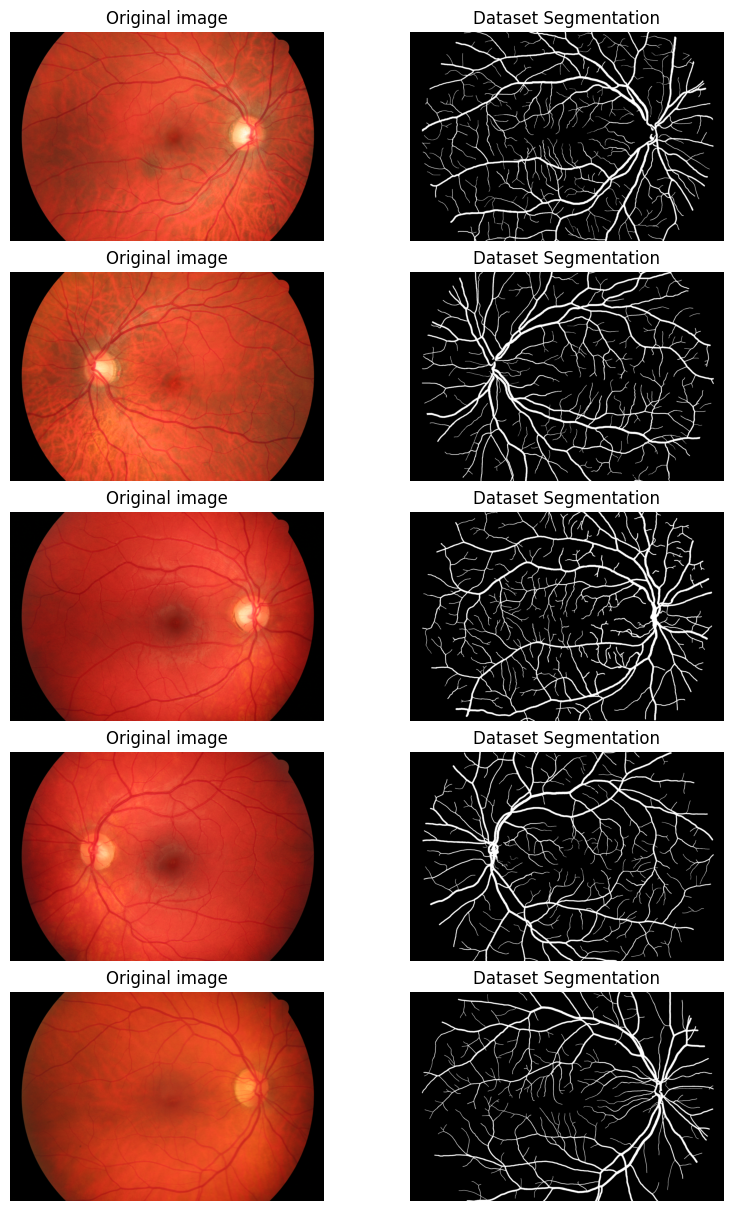

In [82]:
ds = [[],[]]
for i in range(1, 16):
    if i < 10:
        img = cv.imread(f"dataset/healthy/0{i}_h.jpg")
    else:
        img = cv.imread(f"dataset/healthy/{i}_h.jpg")
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    ds[0].append(img)

    if i < 10:
        img = cv.imread(f"dataset/healthy_manualsegm/0{i}_h.tif")
    else:
        img = cv.imread(f"dataset/healthy_manualsegm/{i}_h.tif")
    ds[1].append(img)
ds = np.array(ds)


fig, axes = plt.subplots(5, 2, figsize=(8, 12), constrained_layout=True)
for i in range(5):
    axes[i, 0].imshow(ds[0][i])
    axes[i, 0].set_title("Original image")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(ds[1][i])
    axes[i, 1].set_title("Dataset Segmentation")
    axes[i, 1].axis("off")
plt.show()

# z ciekawości: napisane jest aby używać kanału zielonegow preprezentacji RGB, a co jesli zmienic przestrzeń kolorów?

    odpowiedz można zobaczyć niżej, LAB nie wydaje się pomagać, w kanale A są jakieś informacje ale mocy udział tła, jasnośc też nie wydaje sie byc pomocna

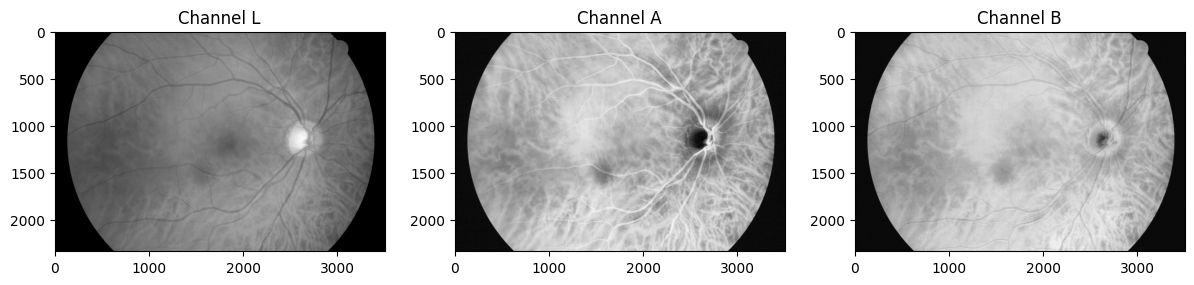

In [6]:
img = ds[0][0]
img = cv.cvtColor(img, cv.COLOR_RGB2LAB)

img_channel = cv.split(img) 
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for i in range(3):
    axes[i].set_title(f"Channel {['L', 'A', 'B'][i]}")
    axes[i].imshow(img_channel[i], cmap="gray")

## a 2YCrCb, czy oko miałby coś wspólnego z skórą?
    Y się wydaje być spoko i Cb też, sprawdźe jak wygląda Y + -Cb

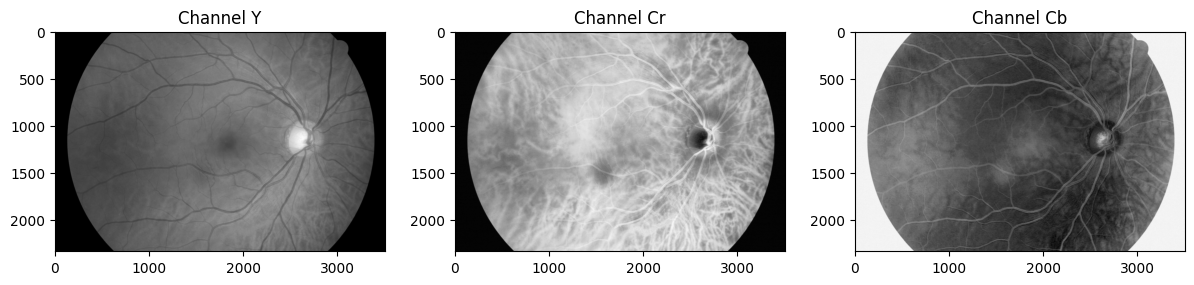

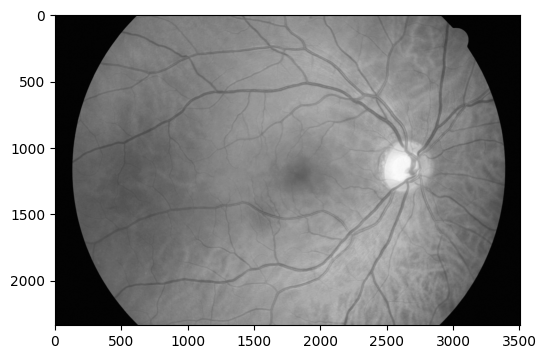

In [16]:
img = ds[0][0]
img = cv.cvtColor(img, cv.COLOR_RGB2BGR)
img = cv.cvtColor(img, cv.COLOR_BGR2YCrCb)
img_channel = cv.split(img)
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for i in range(3):
    axes[i].set_title(f"Channel {['Y', 'Cr', 'Cb'][i]}")
    axes[i].imshow(img_channel[i], cmap="gray")


diff = cv.subtract(img_channel[0].astype(np.int16), img_channel[2].astype(np.int16))

diff_norm = cv.normalize(diff, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(diff_norm, cmap="gray")

#### te rozmyslania i testy zaprowadziły mnie w to samo miejsce, różnica tych 2 kanałów w 'Y', 'Cr', 'Cb' ma wiele wspólnego z po porstu kanałem G w RGB z definicji obu tych przestrzeni barw 

### dla ostatniego jeszcze sprawdzania, HSV
    najbardziej obiecujacy wydaje sie kanał H, ale nadal G w RGB jest po prostu lepszy

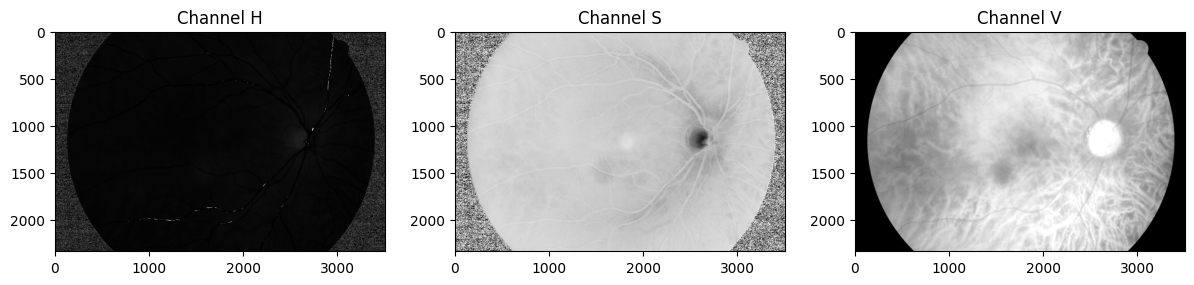

In [18]:
img = ds[0][0]
img = cv.cvtColor(img, cv.COLOR_RGB2BGR)
img = cv.cvtColor(img.astype(np.float32)/255, cv.COLOR_BGR2HSV)
img_channel = cv.split(img)
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for i in range(3):
    axes[i].set_title(f"Channel {['H', 'S', 'V'][i]}")
    axes[i].imshow(img_channel[i], cmap="gray")


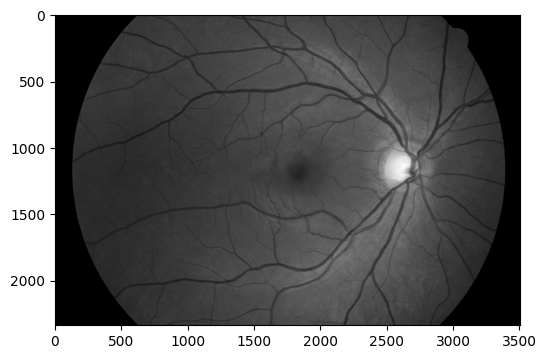

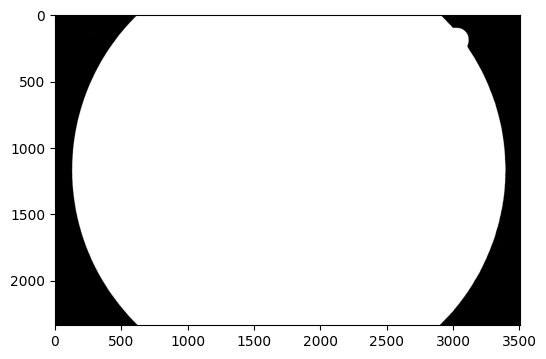

In [38]:
img = cv.split(ds[0][0])[1]
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")

mask = np.zeros_like(img)
mask[img < 4] = 255
mask = ~mask
plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap="gray")

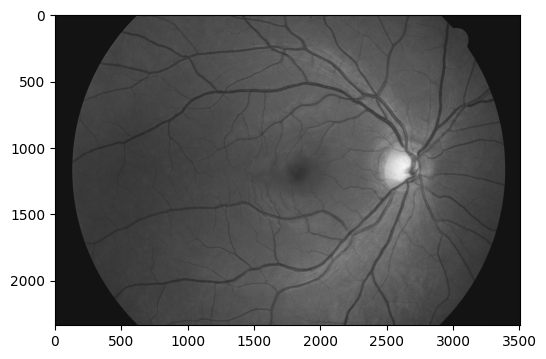

In [40]:
img = cv.split(ds[0][0])[1]
img = img - cv.Laplacian(img, cv.CV_64F)*0.5
img = cv.normalize(img, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
plt.figure(figsize=(6, 6)) 
plt.imshow(img, cmap="gray")

In [41]:
def normalize_masked(img, mask):
    result = np.zeros_like(img, dtype=np.float32)
    
    pixels = img[mask > 0].astype(np.float32)
    
    min_val = pixels.min()
    max_val = pixels.max()
    
    result[mask > 0] = (pixels - min_val) / (max_val - min_val + 1e-8)
    
    return result  # wartości 0.0–1.0, poza maską = 0.0

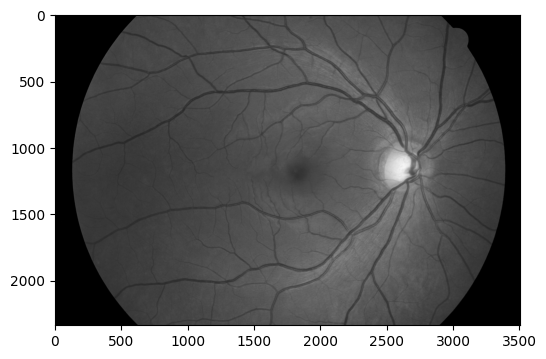

In [42]:
img_mask_norm = normalize_masked(img, mask)
plt.figure(figsize=(6, 6))  
plt.imshow(img_mask_norm, cmap="gray")

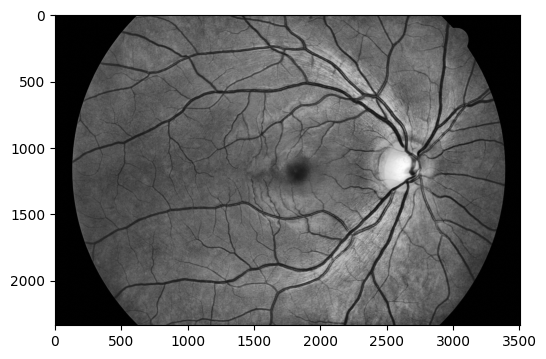

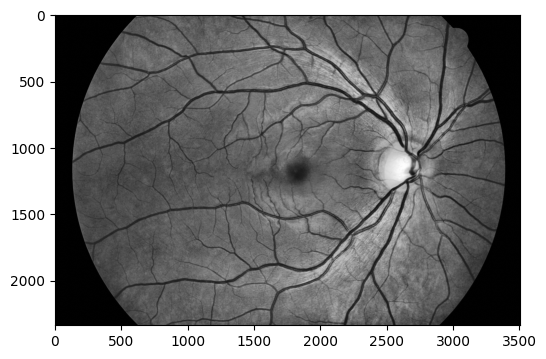

In [56]:
img_uint8 = (img_mask_norm * 255).astype(np.uint8)

clahe = cv.createCLAHE(clipLimit=3.5, tileGridSize=(10, 10))
img_clahe = clahe.apply(img_uint8)

plt.figure(figsize=(6, 6))
plt.imshow(img_clahe, cmap="gray")

img_clahe = cv.medianBlur(img_clahe, 3)  # chciałbym kiedys sprawdzić na ile te blury poprawiają wynik a na ile tracą szczegóły i psują obraz, wydaje się, że ten obraz mędzie miał mało szumu -> sam "aparat" już go redukuje pewnie
plt.figure(figsize=(6, 6))
plt.imshow(img_clahe, cmap="gray")

img = img_clahe


## zadowolony z obecnej formy preprocesu, rozpoczynam podział obrazu na prostokatne 7x7px

In [71]:
print( img_clahe.shape)
print( ds[1][0].shape)


#RObie testowo dla pierszego obrazu, 
truth_mask = ds[1][0]

(2336, 3504)
(2336, 3504, 3)


In [72]:
def extract_features_with_labels(img, expert_mask, roi_mask=None, patch_size=7):
    h, w = img.shape[:2]
    X, Y = [], []
    
    for y in range(0, h - patch_size + 1, patch_size):
        for x in range(0, w - patch_size + 1, patch_size):

            if roi_mask is not None:
                roi_patch = roi_mask[y:y+patch_size, x:x+patch_size]
                if np.count_nonzero(roi_patch) / (patch_size**2) < 0.5:
                    continue
            
            patch      = img[y:y+patch_size, x:x+patch_size]
            mask_patch = expert_mask[y:y+patch_size, x:x+patch_size]
            
            coverage = np.count_nonzero(mask_patch) / (patch_size ** 2)
            label = 1 if coverage >= 0.5 else 0
            
            moments = cv.moments(patch)
            hu = cv.HuMoments(moments).flatten()
            hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
            
            X.append(hu)
            Y.append(label)
    
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.int32)

In [73]:
X, Y = extract_features_with_labels(img, truth_mask, roi_mask=mask)

## Wytestowane na jednym, teraz zrobie pipline dla całego pliku

In [97]:
Xs , Ys = [], []
for i in range(len(ds[0])):
    img = cv.split(ds[0][i])[1]
    truth_mask = ds[1][i]

    mask = np.zeros_like(img)
    mask[img < 4] = 255
    mask = ~mask
    

    img = img - cv.Laplacian(img, cv.CV_64F)*0.5
    img = cv.normalize(img, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

    img_mask_norm = normalize_masked(img, mask)
    img_uint8 = (img_mask_norm * 255).astype(np.uint8)

    clahe = cv.createCLAHE(clipLimit=3.5, tileGridSize=(10, 10))
    img_clahe = clahe.apply(img_uint8)


    img_clahe = cv.medianBlur(img_clahe, 3)  # chciałbym kiedys sprawdzić na ile te blury poprawiają wynik a na ile tracą szczegóły i psują obraz, wydaje się, że ten obraz mędzie miał mało szumu -> sam "aparat" już go redukuje pewnie

    img = img_clahe
    X, Y = extract_features_with_labels(img, truth_mask, roi_mask=mask)
    Xs.append(X)
    Ys.append(Y)


In [99]:
print(f"Xs length: {len(Xs)}")
print(f"Ys length: {len(Ys)}")

print(type(Xs))
print(len(Xs))

for i, x in enumerate(Xs[:5]):
    print(f"[{i}] type={type(x)}, ", end="")
    if hasattr(x, 'shape'):
        print(f"shape={x.shape}, dtype={x.dtype}")
    else:
        print(f"value={x}")

Xs = np.concatenate(Xs, axis=0)  # (n_wszystkich_patchy, 7)
Ys = np.concatenate(Ys, axis=0)  # (n_wszystkich_patchy,)

print(f"Xs.shape: {Xs.shape}")
print(f"Ys.shape: {Ys.shape}")
# Oczekiwane: (~2 115 000, 7)

Xs length: 15
Ys length: 15
<class 'list'>
15
[0] type=<class 'numpy.ndarray'>, shape=(141003, 7), dtype=float32
[1] type=<class 'numpy.ndarray'>, shape=(141016, 7), dtype=float32
[2] type=<class 'numpy.ndarray'>, shape=(140920, 7), dtype=float32
[3] type=<class 'numpy.ndarray'>, shape=(140964, 7), dtype=float32
[4] type=<class 'numpy.ndarray'>, shape=(140975, 7), dtype=float32
Xs.shape: (2114576, 7)
Ys.shape: (2114576,)


In [ ]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

# Zakładam że masz X, Y z poprzedniej funkcji
X_train, X_test, Y_train, Y_test = train_test_split(Xs, Ys, test_size=0.2, random_state=22)

# Skalowanie (ważne dla kNN – wrażliwy na zakresy)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# kNN
knn = KNeighborsClassifier(
    n_neighbors=20,      
    metric='euclidean',
    n_jobs=-1           
)

knn.fit(X_train_scaled, Y_train)

Y_pred = knn.predict(X_test_scaled)
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95    358144
           1       0.84      0.60      0.70     64772

    accuracy                           0.92    422916
   macro avg       0.89      0.79      0.83    422916
weighted avg       0.92      0.92      0.92    422916



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [25,26,27,28],
    'weights':     [ 'distance'],
    'metric':      ['euclidean'],
}

grid = GridSearchCV(KNeighborsClassifier(n_jobs=-1), param_grid, cv=5, scoring='f1')
grid.fit(X_train_scaled, Y_train)

print(grid.best_params_)
print(grid.best_score_)

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score
)
import numpy as np

def evaluate_imbalanced(Y_test, Y_pred, Y_prob=None):
    cm = confusion_matrix(Y_test, Y_pred)
    TN, FP, FN, TP = cm.ravel()

    sensitivity = TP / (TP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)
    ba          = (sensitivity + specificity) / 2
    gmean       = np.sqrt(sensitivity * specificity)

    print(f"Confusion matrix:\n{cm}\n")
    print(f"Sensitivity (Recall cls 1): {sensitivity:.4f}")
    print(f"Specificity (Recall cls 0): {specificity:.4f}")
    print(f"Balanced Accuracy:          {ba:.4f}")
    print(f"G-mean:                     {gmean:.4f}")
    
    if Y_prob is not None:
        auc = roc_auc_score(Y_test, Y_prob)
        print(f"ROC-AUC:                    {auc:.4f}")



knn = KNeighborsClassifier(
    n_neighbors=6,      
    metric='euclidean',
    weights='distance',
    n_jobs=-1           
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

knn.fit(X_train_scaled, Y_train)

Y_pred = knn.predict(X_test_scaled)        
Y_prob = knn.predict_proba(X_test_scaled)[:, 1]
evaluate_imbalanced(Y_test, Y_pred, Y_prob)

Confusion matrix:
[[344616  13528]
 [ 24790  39982]]

Sensitivity (Recall cls 1): 0.6173
Specificity (Recall cls 0): 0.9622
Balanced Accuracy:          0.7898
G-mean:                     0.7707
ROC-AUC:                    0.8579


## do piplinu 

In [ ]:
def preprocess_image(img_rgb):
    print("rozpoczynam preprocessing...")
    """Pełny preprocessing: kanał G → Laplacian → CLAHE → medianBlur"""
    img = cv.split(img_rgb)[1]  # kanał zielony

    # ROI mask (tło = ciemne piksele)
    roi_mask = np.zeros_like(img)
    roi_mask[img < 4] = 255
    roi_mask = ~roi_mask

    # Laplacian sharpening
    img = img - cv.Laplacian(img, cv.CV_64F) * 0.5
    img = cv.normalize(img, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

    # Normalizacja w ROI
    img_norm = normalize_masked(img, roi_mask)
    img_uint8 = (img_norm * 255).astype(np.uint8)

    # CLAHE + median blur
    clahe = cv.createCLAHE(clipLimit=3.5, tileGridSize=(10, 10))
    img_clahe = clahe.apply(img_uint8)
    img_clahe = cv.medianBlur(img_clahe, 3)
    print("preprocessing zakończony.")

    return img_clahe, roi_mask


def segment_image(img_rgb, model, scaler, patch_size=7, threshold=0.5):
    
    print("rozpoczynam segmentację...")
    img_proc, roi_mask = preprocess_image(img_rgb)
    h, w = img_proc.shape[:2]
    pred_mask = np.zeros((h, w), dtype=np.uint8)

    coords = []
    features = []

    for y in range(0, h - patch_size + 1, patch_size):
        for x in range(0, w - patch_size + 1, patch_size):
            roi_patch = roi_mask[y:y+patch_size, x:x+patch_size]
            if np.count_nonzero(roi_patch) / (patch_size**2) < 0.5:
                continue

            patch = img_proc[y:y+patch_size, x:x+patch_size]
            moments = cv.moments(patch)
            hu = cv.HuMoments(moments).flatten()
            hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

            coords.append((y, x))
            features.append(hu)

    # Jeden batch zamiast N pojedynczych wywołań
    features_scaled = scaler.transform(np.array(features))
    probs = model.predict_proba(features_scaled)[:, 1]

    for (y, x), prob in zip(coords, probs):
        if prob >= threshold:
            pred_mask[y:y+patch_size, x:x+patch_size] = 255

    print("segmentacja zakończona.")
    return pred_mask

Confusion matrix:
[[350589   7555]
 [ 29386  35386]]

Sensitivity (Recall cls 1): 0.5463
Specificity (Recall cls 0): 0.9789
Balanced Accuracy:          0.7626
G-mean:                     0.7313
ROC-AUC:                    0.8462


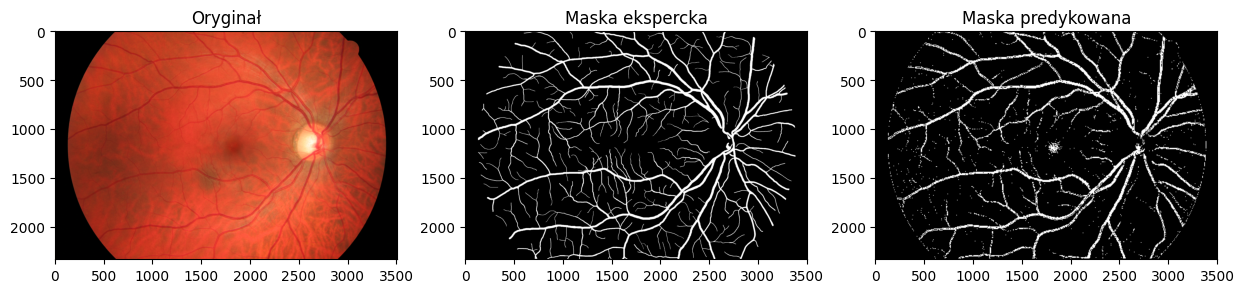

[00] Dice=0.6690  IoU=0.5026
[01] Dice=0.6434  IoU=0.4742
[02] Dice=0.6356  IoU=0.4658


In [ ]:
from sklearn.utils import resample

X_train_sub, Y_train_sub = resample(X_train_scaled, Y_train, n_samples=10000, random_state=42)

knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean',
    algorithm='kd_tree',
    n_jobs=-1
)

knn.fit(X_train_sub, Y_train_sub)

Y_pred = knn.predict(X_test_scaled)
Y_prob = knn.predict_proba(X_test_scaled)[:, 1]
evaluate_imbalanced(Y_test, Y_pred, Y_prob)



mask = segment_image(ds[0][0], knn, scaler)

# Podgląd
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(ds[0][0])
axes[0].set_title("Oryginał")
axes[1].imshow(ds[1][0], cmap="gray")
axes[1].set_title("Maska ekspercka")
axes[2].imshow(mask, cmap="gray")
axes[2].set_title("Maska predykowana")
plt.show()

# Metryki dla całego zbioru


In [ ]:
#dla finalnycvh wyników, robi się strasznie długo, zostawiam na noc

X_train_sub, Y_train_sub = resample(X_train_scaled, Y_train, n_samples=20000, random_state=11)

knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean',
    algorithm='kd_tree',
    n_jobs=-1
)

knn.fit(X_train_sub, Y_train_sub)

Y_pred = knn.predict(X_test_scaled)
Y_prob = knn.predict_proba(X_test_scaled)[:, 1]

evaluate_imbalanced(Y_test, Y_pred, Y_prob)


fig, axes = plt.subplots(5, 3, figsize=(15, 25))

for i in range(1, 6):
    img_rgb = ds[0][i-1]
    expert_mask = ds[1][i-1][:,:,0]

    pred_mask = segment_image(img_rgb, knn, scaler)

    pred_b  = (pred_mask > 0).astype(np.uint8)
    truth_b = (expert_mask > 0).astype(np.uint8)

    TP = np.sum(pred_b & truth_b)
    TN = np.sum(~pred_b.astype(bool) & ~truth_b.astype(bool))
    FP = np.sum(pred_b & ~truth_b.astype(bool))
    FN = np.sum(~pred_b.astype(bool) & truth_b.astype(bool))

    acc   = (TP + TN) / (TP + TN + FP + FN + 1e-8)
    sens  = TP / (TP + FN + 1e-8)
    spec  = TN / (TN + FP + 1e-8)
    bal_a = (sens + spec) / 2
    bal_g = np.sqrt(sens * spec)

    axes[i-1, 0].imshow(img_rgb)
    axes[i-1, 0].set_title(f"[{i}] Oryginał")
    axes[i-1, 0].axis("off")

    axes[i-1, 1].imshow(expert_mask, cmap="gray")
    axes[i-1, 1].set_title("Maska ekspercka")
    axes[i-1, 1].axis("off")

    axes[i-1, 2].imshow(pred_mask, cmap="gray")
    axes[i-1, 2].set_title(
        f"Predykcja\nAcc={acc:.3f} Sens={sens:.3f} Spec={spec:.3f}\nBal_A={bal_a:.3f} Bal_G={bal_g:.3f}"
    )
    axes[i-1, 2].axis("off")

plt.tight_layout()
plt.show()